# E2

In [34]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


### Encuentre el par de estaciones de metro contiguas que tengan mayor diferencia en el costo de construccion de su estructura sobre tierra.


In [35]:
estaciones = gpd.read_file("datos_geoespaciales/Metro 2020/Estaciones_2020/Estaciones_2020.shp")
lineas = gpd.read_file("datos_geoespaciales/Metro 2020/Lineas_2020/Lineas_2020.shp")
distritos = gpd.read_file("datos_geoespaciales/Distritos Censales/Distritos Censales RM.shp")
centroides_distritos = gpd.read_file("datos_geoespaciales/Distritos Censales/centroides Distritos Censales RM.shp")
comunas = gpd.read_file("datos_geoespaciales/Comunas/comunas.shp")

In [36]:
estaciones = estaciones.to_crs(epsg=32719)
distritos = distritos.to_crs(epsg=32719)
lineas = lineas.to_crs(epsg=32719)
centroides_distritos = centroides_distritos.to_crs(epsg=32719)
comunas = comunas.to_crs(epsg=32719)

In [37]:
estaciones.head()

,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,geometry
0,2,2,L2,EL PARRON,El Parrón,345717.3664,6.289105e+06,POINT (345717.366 6289105.444)
1,3,5,L5,CUMMING,Cumming,344899.1198,6.298782e+06,POINT (344899.12 6298781.571)
2,4,5,L5,QUINTA NORMAL,Quinta Normal,343809.1081,6.298628e+06,POINT (343808.803 6298622.125)
3,5,7,L4A,SAN RAMON,San Ramón,346685.4133,6.287624e+06,POINT (347436.975 6287501.27)
4,6,7,L4A,SANTA ROSA,Santa Rosa,348282.5816,6.287378e+06,POINT (348282.582 6287378.409)


In [38]:
distritos.head()

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6..."
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345880.28 6299633.958, 345961.61 629..."
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345546.017 6299748.84, 345650.511 62..."
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((344856.32 6298892.632, 345672.277 62..."
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((343856.526 6298225.435, 344041.982 6..."


1. asignar costo a cada estación

In [39]:
join = gpd.sjoin(estaciones, distritos, predicate="within")

# nos quedamos con el costo, que es el valor de 1 m2 en UF del distrito donde se encuentra cada estación
estaciones_costo = join[["LINEA", "NOMBRE", "1_UF_M2", "geometry", "POINT_X", "POINT_Y"]].copy()

In [40]:
estaciones_costo.head()

,LINEA,NOMBRE,1_UF_M2,geometry,POINT_X,POINT_Y
0,L2,El Parrón,4.97,POINT (345717.366 6289105.444),345717.3664,6.289105e+06
1,L5,Cumming,10.25,POINT (344899.12 6298781.571),344899.1198,6.298782e+06
2,L5,Quinta Normal,5.61,POINT (343808.803 6298622.125),343809.1081,6.298628e+06
3,L4A,San Ramón,5.09,POINT (347436.975 6287501.27),346685.4133,6.287624e+06
4,L4A,Santa Rosa,4.42,POINT (348282.582 6287378.409),348282.5816,6.287378e+06


In [41]:
lineas_disueltas = lineas.dissolve(by="LINEA").reset_index() # va a agrupar los elementos que compartan linea, y los "funde" en un solo elemento.

In [42]:
lineas_disueltas

,LINEA,geometry,OBJECTID,ID_LINEA,LENGTH,Shape_Leng,Shape_Le_1
0,L1,"MULTILINESTRING ((340570.879 6296683.041, 3407...",25,1,14961.079,19600.335826,824.492610
1,L2,"MULTILINESTRING ((345717.366 6289105.444, 3455...",3,2,18315.942,20087.016072,1301.975352
2,L3,"MULTILINESTRING ((354013.447 6297330.697, 3540...",114,3,0.000,22019.504311,20554.018325
3,L4,"MULTILINESTRING ((353644.115 6280922.484, 3536...",92,4,23031.118,23765.896611,922.831328
4,L4A,"MULTILINESTRING ((348282.582 6287378.409, 3482...",84,7,7856.093,8884.086369,1695.676371
5,L5,"MULTILINESTRING ((351409.624 6289970.456, 3514...",54,5,15558.828,30024.141740,825.756156
6,L6,"MULTILINESTRING ((350599.787 6298864.647, 3505...",135,6,0.000,15680.851666,15408.273451


In [43]:
lineas_geom = lineas_disueltas[["LINEA", "geometry"]].rename(columns={"geometry": "geometry_linea"})

In [44]:
estaciones_linea = estaciones_costo.merge(lineas_geom, on="LINEA", how="left")

In [45]:
# líneas válidas (sin COMB) y orden para desempatar
lineas_validas = lineas_geom[lineas_geom["LINEA"] != "COMB"].copy()

orden_lineas = {"L1": 1, "L2": 2, "L3": 3, "L4": 4, "L4A": 5, "L5": 6, "L6": 7}

lineas_validas["orden"] = lineas_validas["LINEA"].map(orden_lineas)

# separar estaciones normales y combinaciones
est_normales = estaciones_costo[estaciones_costo["LINEA"] != "COMB"].copy()
est_comb = estaciones_costo[estaciones_costo["LINEA"] == "COMB"].copy()

# reasignar cada COMB a la línea más cercana; si empata, a la de menor orden
nuevas_lineas = []
for _, est in est_comb.iterrows():
    candidatos = lineas_validas.copy()
    candidatos["dist"] = candidatos["geometry_linea"].distance(est["geometry"])
    candidatos = candidatos.sort_values(["dist", "orden"])
    nuevas_lineas.append(candidatos.iloc[0]["LINEA"])

est_comb["LINEA"] = nuevas_lineas

# reconstruir estaciones_costo con COMB ya reasignadas
estaciones_costo = pd.concat([est_normales, est_comb], ignore_index=True)

In [46]:
estaciones_linea = estaciones_costo.merge(lineas_geom, on="LINEA", how="left")

In [47]:
estaciones_linea["dist_sobre_linea"] = estaciones_linea.apply(
    lambda row: row["geometry_linea"].project(row["geometry"]),
    axis=1
)

2. ordenar las estaciones dentro de cada línea y crear la estación siguiente:

In [48]:
estaciones_linea = estaciones_linea.sort_values(["LINEA", "dist_sobre_linea"]).copy()

estaciones_linea["NOMBRE_sig"] = estaciones_linea.groupby("LINEA")["NOMBRE"].shift(-1)
estaciones_linea["COSTO_sig"] = estaciones_linea.groupby("LINEA")["1_UF_M2"].shift(-1)

3. calcular la diferencia y quedarnos con el mayor:

In [49]:
estaciones_linea["dif_costo"] = abs(estaciones_linea["1_UF_M2"] - estaciones_linea["COSTO_sig"])

pares = estaciones_linea.dropna(subset=["NOMBRE_sig"]).copy()
max_row = pares.loc[pares["dif_costo"].idxmax()]

max_row[["LINEA", "NOMBRE", "NOMBRE_sig", "1_UF_M2", "COSTO_sig", "dif_costo"]]

LINEA                       L4
NOMBRE        Francisco Bilbao
NOMBRE_sig            Tobalaba
1_UF_M2                   8.24
COSTO_sig                40.83
dif_costo                32.59
Name: 21, dtype: object

### Grafique los distritos censales de Santiago para los cuales los habitantes que viven en su centro estan a no mas de 15 minutos caminando de una estacion de metro.

Vamos a asumir que se pueden caminar 5 km en una hora, entonces 15 minutos es 1.25 km. Por lo tanto, vamos a quedarnos con los distritos censales cuyo centroide esté a menos de 1.25 km de una estación de metro.

Como supuesto adicional, nos centraremos en la Santiago Urbano.

In [50]:
centroides_distritos["dist_metro"] = centroides_distritos.geometry.apply(lambda p: estaciones.distance(p).min())

centroides_15min = centroides_distritos[centroides_distritos["dist_metro"] <= 1250].copy()

In [51]:
chile_urbano = gpd.read_file('datos_geoespaciales/Areas Urbanas/areas_urbanas.shp')
santiago_urbano = chile_urbano[chile_urbano['NOMBRE'] == 'Santiago']
santiago_urbano = santiago_urbano.to_crs(epsg=32719)
santiago_urbano.head()

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
385,Santiago,Ciudad,427491.444262,5.821041e+08,"MULTIPOLYGON (((338445.291 6306151.222, 338289..."


In [52]:
# distritos que caen dentro de santiago urbano
distritos_santiago_urb = gpd.sjoin(distritos, santiago_urbano[["geometry"]], how="inner", predicate="intersects").drop(columns=["index_right"])

# centroides accesibles que caen dentro de Santiago urbano, aquí basta within
centroides_15min_santiago_urb = gpd.sjoin(centroides_15min, santiago_urbano[["geometry"]], how="inner", predicate="within").drop(columns=["index_right"])

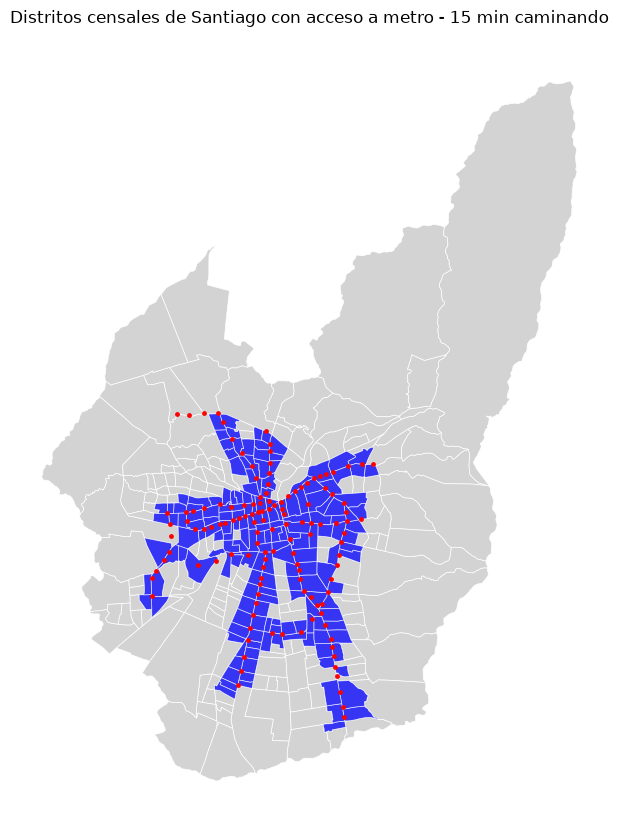

In [53]:
fig, ax = plt.subplots(figsize=(10, 10))

# fondo: todos los distritos de Santiago
distritos_santiago_urb.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)

# encima: distritos accesibles a <= 15 min
distritos_santiago_urb[distritos_santiago_urb["CODIGO"].isin(centroides_15min_santiago_urb["CODIGO"])].plot(
    ax=ax, color="blue", alpha=0.75, edgecolor="white", linewidth=0.5
)

# estaciones de metro
estaciones.plot(ax=ax, color="red", markersize=6)

ax.set_title("Distritos censales de Santiago con acceso a metro - 15 min caminando")
ax.axis("off")

plt.show()

### Estime, para cada linea de metro, el costo de expropiacion de una ciclovia que tenga el mismo trazado, incorporando tambien en el analisis el costo del espacio que utilizaria un estacionamiento de bicicletas por cada estacion de metro.

In [54]:
ancho_ciclovia = 3.0 # metros, por ejemplo ciclovía bidireccional
area_bicicletero = 25.0 # m2 por estación, supuesto

Geometría de cada línea

In [55]:
lineas_disueltas = lineas.dissolve(by="LINEA").reset_index()

# buffer de la ciclovía
lineas_buffer = lineas_disueltas.copy()
lineas_buffer["geometry"] = lineas_buffer.geometry.buffer(ancho_ciclovia / 2)

Costo de expropiación de la ciclovía: área * costo por m2

In [56]:
# intersectar buffer de línea con distritos
inter = gpd.overlay(lineas_buffer[["LINEA", "geometry"]], distritos[["CODIGO", "1_UF_M2", "geometry"]], how="intersection")

# área ocupada dentro de cada distrito
inter["area_m2"] = inter.geometry.area

# costo en UF
inter["costo_ciclovia_UF"] = inter["area_m2"] * inter["1_UF_M2"]

# costo total de ciclovía por línea
costo_ciclovia = (inter.groupby("LINEA", as_index=False)["costo_ciclovia_UF"].sum())

Costo de bicicletero por estación

In [57]:
costo_estaciones = estaciones_costo.copy()
costo_estaciones["costo_bicicletero_UF"] = costo_estaciones["1_UF_M2"] * area_bicicletero

costo_bicicleteros = (costo_estaciones.groupby("LINEA", as_index=False)["costo_bicicletero_UF"].sum())

# opcional: contar estaciones por línea
n_estaciones = (costo_estaciones.groupby("LINEA", as_index=False)["NOMBRE"].count().rename(columns={"NOMBRE": "n_estaciones"}))

Costo por línea

In [58]:
resultado = (costo_ciclovia.merge(costo_bicicleteros, on="LINEA", how="outer").merge(n_estaciones, on="LINEA", how="outer").fillna(0))

resultado["costo_total_UF"] = (resultado["costo_ciclovia_UF"] + resultado["costo_bicicletero_UF"])

resultado = resultado.sort_values("costo_total_UF", ascending=False)

resultado

,LINEA,costo_ciclovia_UF,costo_bicicletero_UF,n_estaciones,costo_total_UF
0,L1,1.167263e+06,11660.00,24,1.178923e+06
5,L5,8.039159e+05,5866.25,26,8.097822e+05
2,L3,6.979186e+05,4652.00,18,7.025706e+05
6,L6,5.473428e+05,2016.75,9,5.493595e+05
1,L2,5.166171e+05,4120.50,24,5.207376e+05
3,L4,5.134432e+05,4253.25,22,5.176964e+05
4,L4A,1.208564e+05,436.25,4,1.212927e+05


### Grafique las comunas urbanas de Santiago, donde cada una esta coloreada con el color de la linea de metro mas cercana. Defina los colores de acuerdo a los oficiales del Metro de Santiago.

In [59]:
import matplotlib.colors as mcolors

todos_los_colores = mcolors.CSS4_COLORS

print(list(todos_los_colores.keys()))


['aliceblue', 'antiquewhite', 'aqua', 'aquamarine', 'azure', 'beige', 'bisque', 'black', 'blanchedalmond', 'blue', 'blueviolet', 'brown', 'burlywood', 'cadetblue', 'chartreuse', 'chocolate', 'coral', 'cornflowerblue', 'cornsilk', 'crimson', 'cyan', 'darkblue', 'darkcyan', 'darkgoldenrod', 'darkgray', 'darkgreen', 'darkgrey', 'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange', 'darkorchid', 'darkred', 'darksalmon', 'darkseagreen', 'darkslateblue', 'darkslategray', 'darkslategrey', 'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgray', 'dimgrey', 'dodgerblue', 'firebrick', 'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'ghostwhite', 'gold', 'goldenrod', 'gray', 'green', 'greenyellow', 'grey', 'honeydew', 'hotpink', 'indianred', 'indigo', 'ivory', 'khaki', 'lavender', 'lavenderblush', 'lawngreen', 'lemonchiffon', 'lightblue', 'lightcoral', 'lightcyan', 'lightgoldenrodyellow', 'lightgray', 'lightgreen', 'lightgrey', 'lightpink', 'lightsalmon', 'lightseagreen', 

In [60]:
colores_metro = {
    "L1": "crimson",     
    "L2": "gold",      
    "L3": "sienna",       
    "L4": "dodgerblue",  
    "L4A": "skyblue",    
    "L5": "forestgreen",  
    "L6": "darkmagenta"
}


In [61]:
# comunas urbanas de Santiago
comunas_urbanas = gpd.sjoin(comunas.to_crs(epsg=32719), santiago_urbano[["geometry"]], how="inner", predicate="intersects").drop(columns="index_right")

# una geometría por línea
# lineas_disueltas = lineas.to_crs(epsg=32719).dissolve(by="LINEA").reset_index()

lineas_disueltas = (lineas[lineas["LINEA"].isin(colores_metro)].dissolve(by="LINEA").reset_index())

# comuna -> línea más cercana
comunas_linea = gpd.sjoin_nearest(
    comunas_urbanas,
    lineas_disueltas[["LINEA", "geometry"]],
    how="left",
    distance_col="dist_linea"
)

comunas_linea["color_linea"] = comunas_linea["LINEA"].map(colores_metro)

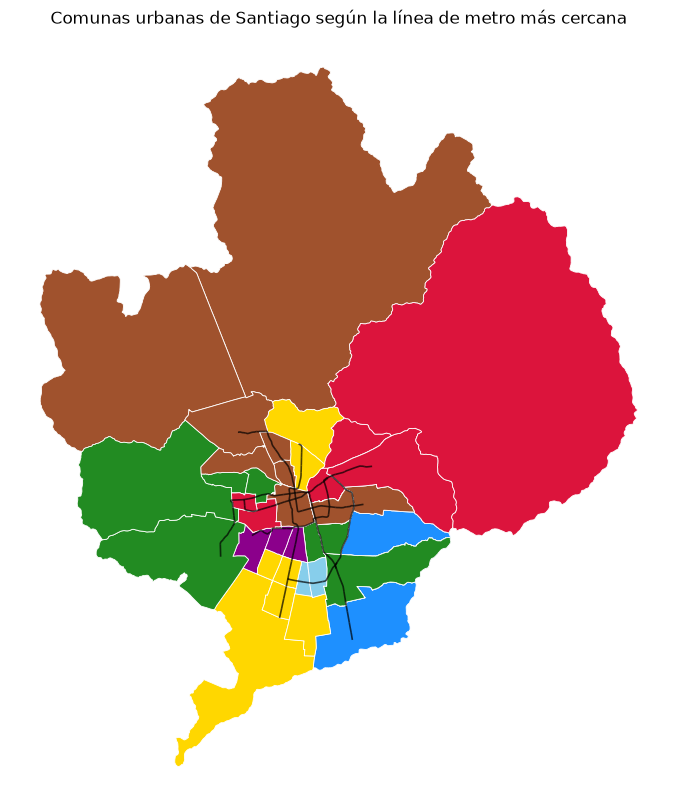

In [62]:
fig, ax = plt.subplots(figsize=(10, 10))

comunas_linea.plot(
    ax=ax,
    color=comunas_linea["color_linea"],
    edgecolor="white",
    linewidth=0.6
)

lineas_disueltas.plot(ax=ax, color="black", linewidth=1.2, alpha=0.7)

ax.set_title("Comunas urbanas de Santiago según la línea de metro más cercana")
ax.axis("off")
plt.show()

### PROPUESTO

### Diseñe una nueva linea de metro (trazado y estaciones) que cumpla con las siguientes exigencias:

• Una extension aproximadamente igual al promedio de las lineas ya existentes.

• Distancia entre estaciones aproximadamente igual al promedio de las ya existentes.

• La proporcion de cada grupo socioeconomico en los distritos cruzados debe ser similar al promedio del resto de las lineas existentes.

• 75% de las estaciones ubicadas en distritos que actualmente no tienen estaciones.

• El cruce con otra linea debe ser en una estacion que pase por ambas

In [63]:
# Longitud promedio de las lineas existentes (sin COMB)
grupos = ["E", "D", "C3", "C2", "ABC1"]
lineas_disueltas = lineas[lineas["LINEA"] != "COMB"].dissolve(by="LINEA").reset_index()
longitud_promedio = lineas_disueltas.geometry.length.mean()

# Distritos que actualmente tienen estaciones
distritos_con_estacion = gpd.sjoin(
    distritos[["CODIGO", "geometry"]],
    estaciones[["geometry"]],
    how="inner",
    predicate="intersects"
)["CODIGO"].unique()

# Asignar a una linea real las estaciones marcadas como COMB
join_est = gpd.sjoin(
    estaciones,
    distritos[["CODIGO", "E", "D", "C3", "C2", "ABC1", "geometry"]],
    how="left",
    predicate="within"
).drop(columns="index_right")

estaciones_costo = join_est[["LINEA", "NOMBRE", "CODIGO", "E", "D", "C3", "C2", "ABC1", "geometry"]].copy()
lineas_geom = lineas_disueltas[["LINEA", "geometry"]].rename(columns={"geometry": "geometry_linea"})
lineas_validas = lineas_geom.copy()
orden_lineas = {"L1": 1, "L2": 2, "L3": 3, "L4": 4, "L4A": 5, "L5": 6, "L6": 7}
lineas_validas["orden"] = lineas_validas["LINEA"].map(orden_lineas)

est_normales = estaciones_costo[estaciones_costo["LINEA"] != "COMB"].copy()
est_comb = estaciones_costo[estaciones_costo["LINEA"] == "COMB"].copy()
nuevas_lineas = []

for _, est in est_comb.iterrows():
    candidatos = lineas_validas.copy()
    candidatos["dist"] = candidatos["geometry_linea"].distance(est["geometry"])
    nuevas_lineas.append(candidatos.sort_values(["dist", "orden"]).iloc[0]["LINEA"])

est_comb["LINEA"] = nuevas_lineas
estaciones_costo = pd.concat([est_normales, est_comb], ignore_index=True)
estaciones_costo = estaciones_costo.drop_duplicates(["LINEA", "NOMBRE"])
estaciones_cruce = estaciones_costo.reset_index(drop=True)

# Distancia promedio entre estaciones consecutivas
est_tmp = estaciones_costo.merge(lineas_geom, on="LINEA", how="left")
est_tmp["dist_sobre_linea"] = est_tmp.apply(
    lambda row: row["geometry_linea"].project(row["geometry"]), axis=1
)
est_tmp = est_tmp.sort_values(["LINEA", "dist_sobre_linea"])
est_tmp["dist_sig"] = est_tmp.groupby("LINEA")["dist_sobre_linea"].shift(-1) - est_tmp["dist_sobre_linea"]
dist_promedio_estaciones = est_tmp["dist_sig"].dropna().mean()

# Perfil objetivo: proporciones en los distritos que cruza cada linea
lineas_distritos = gpd.sjoin(
    lineas_disueltas[["LINEA", "geometry"]],
    distritos[grupos + ["geometry"]],
    how="inner",
    predicate="intersects"
)
lineas_distritos[grupos] = lineas_distritos[grupos].div(
    lineas_distritos[grupos].sum(axis=1), axis=0
)
comp_linea = lineas_distritos.groupby("LINEA")[grupos].mean()
comp_objetivo = comp_linea.mean()

print(f"Longitud promedio: {round(longitud_promedio, 2)} m")
print(f"Distancia promedio entre estaciones: {round(dist_promedio_estaciones, 2)} m")
print(f"Proporciones socioeconomicas objetivo:")
print(comp_objetivo.round(3))

Longitud promedio: 20591.15 m
Distancia promedio entre estaciones: 1146.18 m
Proporciones socioeconomicas objetivo:
E       0.035
D       0.263
C3      0.340
C2      0.280
ABC1    0.082
dtype: float64


In [64]:
from shapely.geometry import LineString
import numpy as np

def construir_linea_desde_cruce(punto, theta, largo):
    dx = np.cos(theta) * largo / 2
    dy = np.sin(theta) * largo / 2
    return LineString([(punto.x - dx, punto.y - dy), (punto.x + dx, punto.y + dy)])

def generar_estaciones(linea, punto_cruce, dist_prom):
    dist_cruce = linea.project(punto_cruce)
    dist_izq = np.arange(dist_cruce, -1, -dist_prom)[::-1]
    dist_der = np.arange(dist_cruce + dist_prom, linea.length + 1e-9, dist_prom)
    distancias = np.concatenate([dist_izq, dist_der])
    return gpd.GeoDataFrame(
        {"dist_sobre_linea": distancias},
        geometry=[linea.interpolate(d) for d in distancias],
        crs=distritos.crs
    )

def evaluar_candidata(linea, estaciones_nuevas):
    # una estacion cuenta como nueva solo si cae en un distrito sin estaciones
    est_dist = gpd.sjoin(
        estaciones_nuevas,
        distritos[["CODIGO", "geometry"]],
        how="left",
        predicate="within"
    ).drop(columns="index_right")
    
    prop_sin = (est_dist["CODIGO"].notna() & ~est_dist["CODIGO"].isin(distritos_con_estacion)).mean()

    # Comparar proporciones de grupos en los distritos cruzados
    linea_gdf = gpd.GeoDataFrame({"id": [1]}, geometry=[linea], crs=distritos.crs)
    
    distr_cruz = gpd.sjoin(
        distritos[grupos + ["geometry"]],
        linea_gdf,
        how="inner",
        predicate="intersects"
    )
    proporciones = distr_cruz[grupos].div(distr_cruz[grupos].sum(axis=1), axis=0)
    comp_nueva = proporciones.mean()
    dist_soc = np.linalg.norm(comp_nueva.values - comp_objetivo.values)

    return {"prop_sin": prop_sin, "dist_soc": dist_soc, "n_estaciones": len(estaciones_nuevas)}

resultados = []
angulos = np.deg2rad(np.arange(0, 180, 5))

for id_cruce, est in estaciones_cruce.iterrows():
    for theta in angulos:
        linea = construir_linea_desde_cruce(est.geometry, theta, longitud_promedio)
        estaciones_cand = generar_estaciones(linea, est.geometry, dist_promedio_estaciones)
        resultados.append({
            "id_cruce": id_cruce,
            "cruce": est["NOMBRE"],
            "linea_cruce": est["LINEA"],
            "theta_deg": np.rad2deg(theta),
            **evaluar_candidata(linea, estaciones_cand)
        })

resultados = pd.DataFrame(resultados)
resultados.head()

,id_cruce,cruce,linea_cruce,theta_deg,prop_sin,dist_soc,n_estaciones
0,0,El Parrón,L2,0.0,0.823529,0.103361,17
1,0,El Parrón,L2,5.0,0.823529,0.120311,17
2,0,El Parrón,L2,10.0,0.764706,0.103781,17
3,0,El Parrón,L2,15.0,0.764706,0.126643,17
4,0,El Parrón,L2,20.0,0.764706,0.109815,17


In [65]:
# elegir la mejor candidata que cumple el minimo de 75%
resultados_validos = resultados[resultados["prop_sin"] >= 0.75]
mejor = resultados_validos.sort_values("dist_soc").iloc[0]

estacion_obj = estaciones_cruce.loc[int(mejor["id_cruce"])]
punto_cruce = estacion_obj.geometry
theta = np.deg2rad(mejor["theta_deg"])

linea_nueva = construir_linea_desde_cruce(punto_cruce, theta, longitud_promedio)
estaciones_nuevas = generar_estaciones(linea_nueva, punto_cruce, dist_promedio_estaciones)
linea_nueva_gdf = gpd.GeoDataFrame(
    {"cruce": [mejor["cruce"]], "linea_cruce": [mejor["linea_cruce"]]},
    geometry=[linea_nueva],
    crs=distritos.crs
)

print(f"Cruce: {mejor['cruce']} en {mejor['linea_cruce']}")
print(f"Largo: {round(linea_nueva.length, 2)} m")
print(f"Estaciones: {len(estaciones_nuevas)}")
print(f"Proporcion en distritos sin estaciones: {round(mejor['prop_sin'] * 100, 1)}%")
print(f"Diferencia de composicion socioeconomica: {round(mejor['dist_soc'], 3)}")

Cruce: Cerro Blanco en L2
Largo: 20591.15 m
Estaciones: 17
Proporcion en distritos sin estaciones: 76.5%
Diferencia de composicion socioeconomica: 0.003


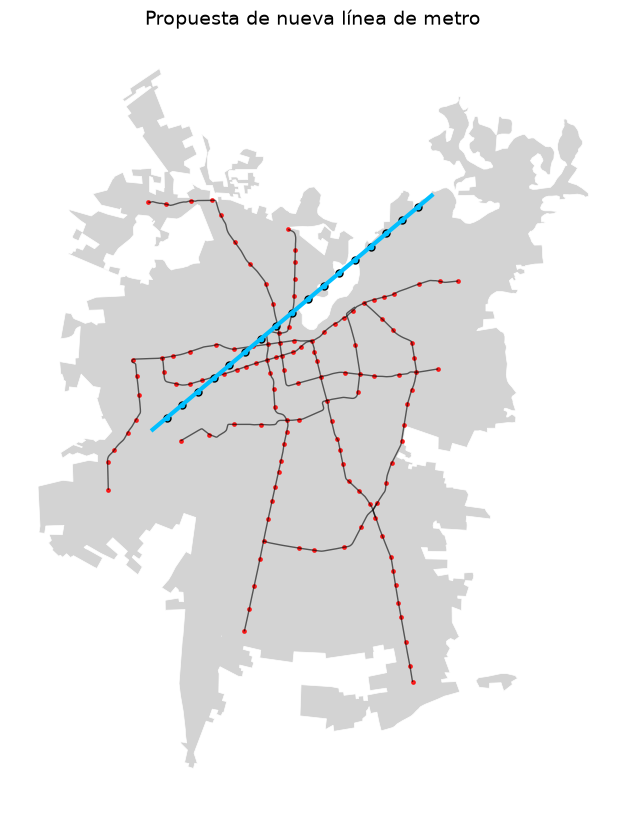

In [66]:
fig, ax = plt.subplots(figsize=(10, 10))

# santiago urbano de fondo
santiago_urbano.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)

# líneas existentes
lineas_disueltas.plot(ax=ax, color="black", linewidth=1, alpha=0.6)

# estaciones existentes
estaciones.plot(ax=ax, color="red", markersize=6, alpha=0.8)

# nueva línea
linea_nueva_gdf.plot(ax=ax, color="deepskyblue", linewidth=3)

# nuevas estaciones
estaciones_nuevas.plot(ax=ax, color="deepskyblue", markersize=25, edgecolor="black")

ax.set_title("Propuesta de nueva línea de metro", fontsize=14)
ax.axis("off")

plt.show()